In [30]:
import torch
import numpy as np
import warnings
import matplotlib
warnings.filterwarnings("ignore", category=DeprecationWarning)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import sys, os

# Adjust these paths to match your project
sys.path.append('../src/')  # <-- change this

from dataloaders import PREPROC_MAPPER
from dataloaders.utils import get_dataset, ZeroShotSamplerReduced
from dataloaders import DiskDatasetDiv
from torch.utils.data import Subset


In [42]:
# --- Config: adjust these to match your yaml/setup ---
DATA_BASE       = '../datasets/prjs1359/'       # cb.data_base
DATASET_NAME    = 'amira'    # item["name"]
TEMPORAL_BUNDLE = 5                      # cm.temporal_bundling
TRAIN_RATIO     = 0.8                    # ct.train_ratio
SEED            = 227                     # cd.seed
TIMESAMPLE      = 1                      # item["timesample"]


preproc_path = DATA_BASE + "preproc_" + DATASET_NAME
dataset = DiskDatasetDiv(preproc_path, temporal_bundling=TEMPORAL_BUNDLE, forward_steps=1)

val_sampler = ZeroShotSamplerReduced(
    dataset, train_ratio=TRAIN_RATIO,
    split="val", seed=SEED, skip_timesteps=TIMESAMPLE
)
val_subset = Subset(dataset, val_sampler.indices)

print(f"Dataset loaded: {len(val_subset)} validation samples")
print(f"Data shape: {dataset.datashape}")
print(f"Mean: {dataset.avg:.4f}, Std: {dataset.std:.4f}")

Dataset loaded: 1529600 validation samples
Data shape: (np.int64(7999), np.int64(1001), np.int64(2), np.int64(128), np.int64(128))
Mean: -0.0002, Std: 0.2530


Trajectory shape: torch.Size([201, 2, 128, 128])  (T, C, H, W)


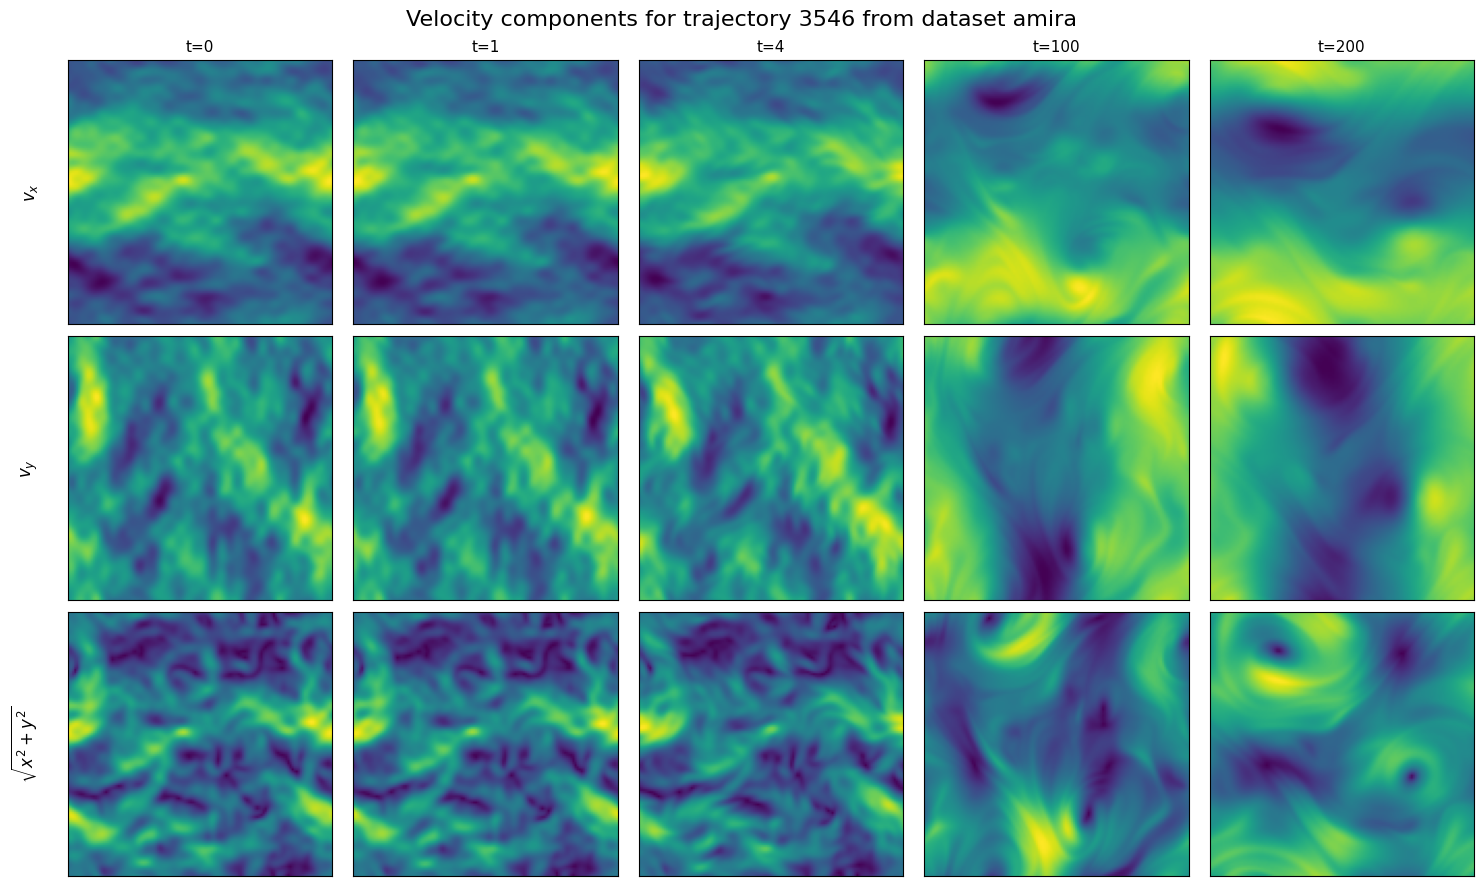

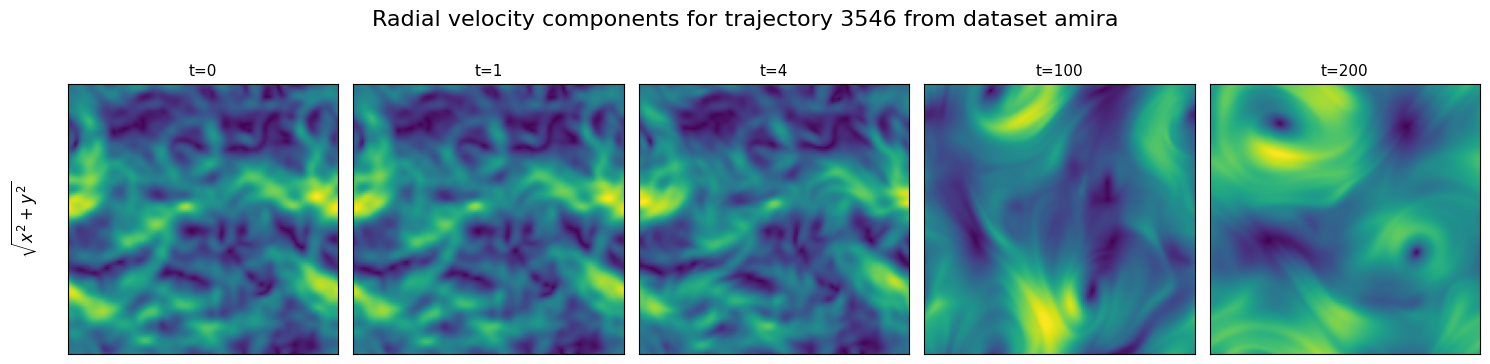

In [45]:
# Pick a random trajectory index from validation set
traj_idx = val_sampler.random_val_traj()
traj = dataset.get_single_traj(traj_idx)  # shape: (T, C, H, W)

global_mean = dataset.avg
global_std  = dataset.std

# Denormalize
traj_denorm = traj.float() * global_std + global_mean

print(f"Trajectory shape: {traj.shape}  (T, C, H, W)")
#print(f"Value range after denorm: [{traj_denorm.min():.3f}, {traj_denorm.max():.3f}]")

N_STEPS_TO_PLOT = 5
CHANNEL_X = 0
CHANNEL_Y = 1

T = traj_denorm.shape[0]
timesteps = [0, 1, 4, T//2, T - 1]
fig, axes = plt.subplots(3, len(timesteps), figsize=(3 * len(timesteps), 9))
fig.suptitle(f"Velocity components for trajectory {traj_idx} from dataset {DATASET_NAME}", fontsize=16)

for col, t in enumerate(timesteps):
    frame = traj_denorm[t]  # (C, H, W)

    vx = frame[CHANNEL_X]
    vy = frame[CHANNEL_Y]
    vr = np.sqrt(vx**2 + vy**2)

    for row, (data, label) in enumerate([
        (vx, r"$v_x$"),
        (vy, r"$v_y$"),
        (vr, r"$\sqrt{x^2 + y^2}$"),
    ]):
        ax = axes[row, col]
        im = ax.imshow(data.numpy(), cmap="viridis", origin="lower")
        ax.set_xticks([])
        ax.set_yticks([])

        if row == 0:    
            ax.set_title(f"t={t}", fontsize=11)
        if col == 0:
            ax.set_ylabel(label, fontsize=12, rotation=90, labelpad=20)

plt.tight_layout()

plt.savefig('temp/lalala.png')
plt.show()

fig, axes = plt.subplots(1, len(timesteps), figsize=(3 * len(timesteps), 4))
fig.suptitle(f"Radial velocity components for trajectory {traj_idx} from dataset {DATASET_NAME}", fontsize=16)
ax = axes.flatten()
for col, t in enumerate(timesteps):
    frame = traj_denorm[t]  # (C, H, W)

    vx = frame[CHANNEL_X]
    vy = frame[CHANNEL_Y]
    data = np.sqrt(vx**2 + vy**2)
    im = ax[col].imshow(data.numpy(), cmap="viridis", origin="lower")
    ax[col].set_xticks([])
    ax[col].set_yticks([])

    ax[col].set_title(f"t={t}", fontsize=11)
    if col == 0:
        ax[col].set_ylabel(r"$\sqrt{x^2+y^2}$", fontsize=12, rotation=90, labelpad=20)

plt.tight_layout()

plt.savefig('temp/lalala2.png')
plt.show()

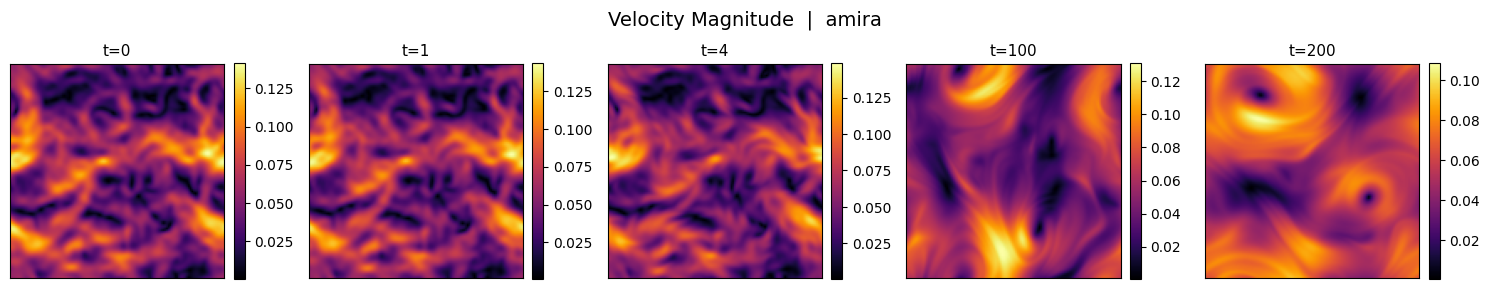

In [46]:
fig, axes = plt.subplots(1, len(timesteps), figsize=(3 * len(timesteps), 3))
fig.suptitle(f"Velocity Magnitude  |  {DATASET_NAME}", fontsize=14)

for col, t in enumerate(timesteps):
    frame = traj_denorm[t]
    mag = torch.sqrt(frame[CHANNEL_X]**2 + frame[CHANNEL_Y]**2).numpy()
    ax = axes[col]
    im = ax.imshow(mag, cmap='inferno', origin='lower')
    ax.set_title(f"t={t}", fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()